In [1]:
import pandas as pd
import sqlite3
import os
from pathlib import Path
import numpy
import seaborn as sns
import peewee as pw
import matplotlib.pyplot as plt
import sklearn as skl

os.chdir(r'c:\Repositories\asphalt-db')
#swithc working directory to 
from src.db_builder.models import *
sns.set_style('whitegrid')
working_dir = Path(r'c:\Repositories\asphalt-db\results')

In [2]:
#connect to database using sqlite3/pands

conn = sqlite3.connect(working_dir.joinpath('database_all_v3.sqlite'))

In [3]:
pd.read_sql("SELECT name FROM sqlite_master WHERE type='table';", conn)



,name
0,project
1,dijk
2,projectdijk
3,borehole
4,sample
5,test
6,bezwijksterkteruwe
7,bezwijksterkteprocessed
8,bezwijksterktesummary
9,generaldata


In [4]:

query = """
SELECT 
    b.id AS borehole_id,
    b.project_dijk_id AS project_dike_id,
    b.aanlegjaar AS construction_year,
    b.onderzoeksjaar AS investigation_year,
    pd.project_id AS project_id,
    pd.dijk_id AS dike_id,
    p.project_name AS project_name,
    d.dike_name AS dike_name,
    d.waterboard as waterboard
FROM Borehole b
JOIN ProjectDijk pd ON b.project_dijk_id = pd.id
JOIN Project p ON pd.project_id = p.id
JOIN DIJK d ON pd.dijk_id = d.id
"""


# Read into a pandas DataFrame
dikes_and_projects = pd.read_sql(query, conn)
dikes_and_projects['age_at_investigation'] = dikes_and_projects['investigation_year'] - dikes_and_projects['construction_year']

dikes_and_projects.head()
# dikes_and_projects.columns

,borehole_id,project_dike_id,construction_year,investigation_year,project_id,dike_id,project_name,dike_name,waterboard,age_at_investigation
0,1,1,1984,2006,1,1,P_0601831,"het_flaauwe_werk_29,6 - 48,5",Hollandse Delta,22
1,2,1,1984,2006,1,1,P_0601831,"het_flaauwe_werk_29,6 - 48,5",Hollandse Delta,22
2,3,1,1984,2006,1,1,P_0601831,"het_flaauwe_werk_29,6 - 48,5",Hollandse Delta,22
3,4,1,1984,2006,1,1,P_0601831,"het_flaauwe_werk_29,6 - 48,5",Hollandse Delta,22
4,5,1,1984,2006,1,1,P_0601831,"het_flaauwe_werk_29,6 - 48,5",Hollandse Delta,22


In [5]:
# #load the BezwijksterkteSummary table (all columns) and connect to Test, Sample and Borehole to get the corresponding Borehole

query = """
SELECT 
    b.id AS borehole_id,
    s.id AS sample_id,
    t.test_name AS test_name,
    bzs.*
FROM Borehole b
JOIN Sample s ON s.borehole_id = b.id
JOIN Test t ON t.sample_id = s.id
JOIN BezwijksterkteSummary bzs ON bzs.test_id = t.id
"""
df_bzs = pd.read_sql(query, conn)

#drop HR column because it has only 0's
# df_bzs = df_bzs.drop(columns=['HR'])
df_bzs = df_bzs.drop_duplicates(subset=['sample_id', 'test_name'], keep='first')

df_bzs.sort_values('borehole_id').head()



,borehole_id,sample_id,test_name,id,test_id,sample_name,v,Sec_10,Sec_50,Sec_100,sig_b,eps_b,G_c,G_c_over_eps_b,G_c_over_eps_b_sig_b,V_Ber
0,1,1,T_k1-b1,1,1,k1-b1,0.140012,845.411263,682.612478,469.888848,6.259762,13307.685104,1220.385972,0.091705,0.014650,0.289319
1,2,4,T_k2-b1,2,4,k2-b1,0.096297,1212.461276,772.955418,535.381092,5.381163,10049.202919,790.309841,0.078644,0.014615,0.294647
2,3,7,T_k3-b1,3,7,k3-b1,0.082952,937.031495,579.948853,352.859425,4.876932,13780.406940,1056.284704,0.076651,0.015717,0.381887
3,4,10,T_k4-b1,4,10,k4-b1,0.083127,1180.725811,828.712848,537.120868,6.708308,12456.420151,1309.306443,0.105111,0.015669,0.371331
4,5,13,T_k5-b1,5,13,k5-b1,0.083283,955.572918,500.039983,289.317153,4.720396,16308.786975,1308.015356,0.080203,0.016991,0.501078


In [6]:
#do the same for VermoeiingSummary
# query = """
# SELECT
#     b.id AS borehole_id,
#     g.sample_id AS sample_id,
#     g.HR AS HR,
#     t.test_name AS test_name,
#     vs.*
# FROM Borehole b
# JOIN Sample s ON s.borehole_id = b.id
# JOIN Test t ON t.sample_id = s.id
# JOIN GeneralData g ON s.id = g.sample_id
# JOIN VermoeiingSummary vs ON vs.test_id = t.id

# """
query = """
SELECT
    b.id AS borehole_id,
    s.id AS sample_id,
    t.test_name AS test_name,
    vs.*
FROM Borehole b
JOIN Sample s ON s.borehole_id = b.id
JOIN Test t ON t.sample_id = s.id
JOIN VermoeiingSummary vs ON vs.test_id = t.id

"""

df_vs = pd.read_sql(query, conn)
#drop duplicate rows based on sample_id and test_name and ensure that dropped duplicates have the same values in all columns
df_vs = df_vs.drop_duplicates(subset=['sample_id', 'test_name'], keep='first')
df_vs.drop(columns=['id'], inplace=True)
df_vs.head()

,borehole_id,sample_id,test_name,test_id,sample_name,pha_ini,pha_50,sig_cyc,sig_perm,E_ini,E_50,N_fat
0,1,2,T_K1-b2,2,K1-b2,13.4,12.8,3.868148,0.118556,2366.0,2436.0,490
1,2,5,T_K2-b2b,5,K2-b2b,13.3,11.4,1.366593,0.114648,1826.0,2296.0,24000
2,3,8,T_K3-b2b,8,K3-b2b,13.6,13.1,2.781395,0.116814,2302.0,2157.0,2000
3,4,11,T_K4-b2,11,K4-b2,10.7,9.0,1.687917,0.116208,1859.0,2615.0,29000
4,5,14,T_K5-b2b,14,K5-b2b,12.6,11.5,2.282727,0.114500,2389.0,2209.0,2500


In [7]:
#get HR & bitumen

query = """
SELECT
    b.id AS borehole_id,
    g.*
FROM GeneralData g
JOIN Sample s ON s.id = g.sample_id
JOIN Borehole b ON b.id = s.borehole_id
"""

df_general = pd.read_sql(query, conn)

#check if all HR and bitumen are the same for each borehole_id
df_general = df_general[['borehole_id', 'HR', 'bitumen']].drop_duplicates().sort_values('borehole_id')
# only 1 entry per borehole_id

if df_general['borehole_id'].value_counts().max() > 1:
    raise Exception("Warning: There are different HR and/or bitumen values for some borehole_id in df_general. Please check the GeneralData.")




In [8]:
#join general data to dikes_and_projects on borehole_id
df_merge_1 = pd.merge(dikes_and_projects, df_general, on='borehole_id', how = 'left')

#join df_bzs to dikes_and_projects on borehole_id
df_merge_2 = pd.merge(df_merge_1, df_bzs, on='borehole_id', how='left',suffixes=('_dike', '_bzs'))
df_merge_2.head()


#join df_vs to df_merge_1 on borehole_id
df_final = pd.merge(df_merge_2, df_vs, on='borehole_id', how='left', suffixes=('_bzs', '_vs'))
df_final.head()

#add column of HR-categories
def categorize_hr(hr):
    if hr < 3:
        return 'HR <3%'
    elif 3 <= hr < 6:
        return 'HR 3-6%'
    elif 6 <= hr < 9:
        return 'HR 6-9%'
    else:
        return 'HR >9%'
df_final['HR_category'] = df_final['HR'].apply(categorize_hr)
df_final.head()


,borehole_id,project_dike_id,construction_year,investigation_year,project_id,dike_id,project_name,dike_name,waterboard,age_at_investigation,...,test_id_vs,sample_name_vs,pha_ini,pha_50,sig_cyc,sig_perm,E_ini,E_50,N_fat,HR_category
0,1,1,1984,2006,1,1,P_0601831,"het_flaauwe_werk_29,6 - 48,5",Hollandse Delta,22,...,2.0,K1-b2,13.4,12.8,3.868148,0.118556,2366.0,2436.0,490.0,HR 3-6%
1,2,1,1984,2006,1,1,P_0601831,"het_flaauwe_werk_29,6 - 48,5",Hollandse Delta,22,...,5.0,K2-b2b,13.3,11.4,1.366593,0.114648,1826.0,2296.0,24000.0,HR 3-6%
2,3,1,1984,2006,1,1,P_0601831,"het_flaauwe_werk_29,6 - 48,5",Hollandse Delta,22,...,8.0,K3-b2b,13.6,13.1,2.781395,0.116814,2302.0,2157.0,2000.0,HR 3-6%
3,4,1,1984,2006,1,1,P_0601831,"het_flaauwe_werk_29,6 - 48,5",Hollandse Delta,22,...,11.0,K4-b2,10.7,9.0,1.687917,0.116208,1859.0,2615.0,29000.0,HR 3-6%
4,5,1,1984,2006,1,1,P_0601831,"het_flaauwe_werk_29,6 - 48,5",Hollandse Delta,22,...,14.0,K5-b2b,12.6,11.5,2.282727,0.114500,2389.0,2209.0,2500.0,HR 3-6%


<Axes: xlabel='age_at_investigation', ylabel='sig_b'>

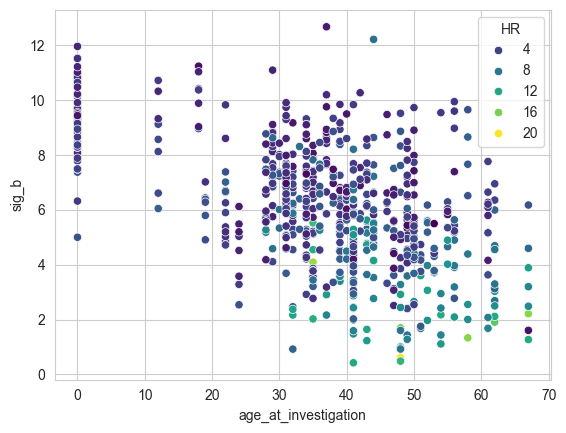

In [9]:
#make as scatter plot of age_at_investigation vs sig_b, colored by HR_category
sns.scatterplot(data=df_final, x='age_at_investigation', y='sig_b', hue='HR',palette='viridis')

In [10]:
data_for_regression = df_final[['borehole_id','age_at_investigation', 'sig_b', 'HR']]
#rename sig_b to str and age_at_investigation to age and HR to void
data_for_regression = data_for_regression.rename(columns={'sig_b':'str', 'age_at_investigation':'age', 'HR':'void'})
#export to xlsx
data_for_regression.to_excel(working_dir.joinpath('data_for_regression.xlsx'), index=False)
                               
    

<Axes: xlabel='age_at_investigation', ylabel='sig_b'>

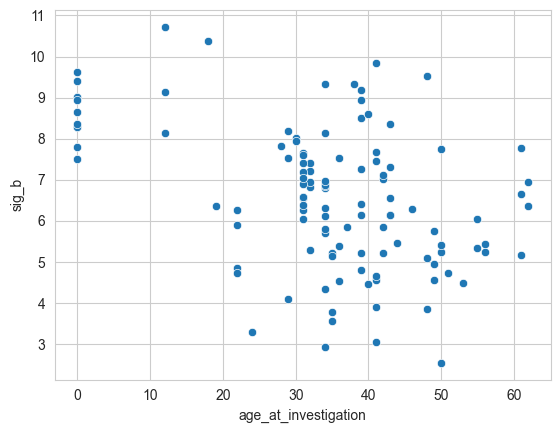

In [11]:
#plot only for HR 3.5-4.5
sns.scatterplot(data=df_final[df_final['HR'].between(3.5,4.5)], x='age_at_investigation', y='sig_b')


In [12]:
columns = ['v','Sec_10', 'Sec_50', 'sig_b', 'eps_b', 'G_c', 'pha_50', 'sig_cyc', 'E_50', 'N_fat','age_at_investigation']
# sns.pairplot(df_merged, vars=columns, hue='HR_category')
for col in columns:
    fig, ax = plt.subplots()
    sns.histplot(data=df_final, x=col, hue='HR_category', kde=True, ax=ax)
    ax.set_title(f'Distribution of {col} by HR Category')
    plt.savefig(working_dir.joinpath(f'{col}_distribution_by_HR_category_new.png'))
    plt.close()

<Axes: xlabel='G_c', ylabel='sig_b'>

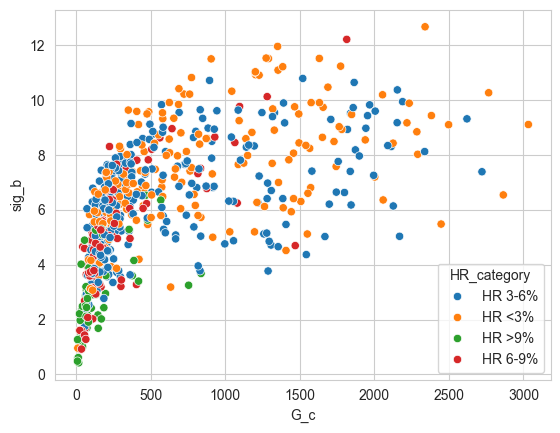

In [13]:
#scatterplot of v and sig_b
sns.scatterplot(data=df_final, x='G_c', y='sig_b', hue='HR_category')


<Axes: xlabel='age_at_investigation', ylabel='sig_b'>

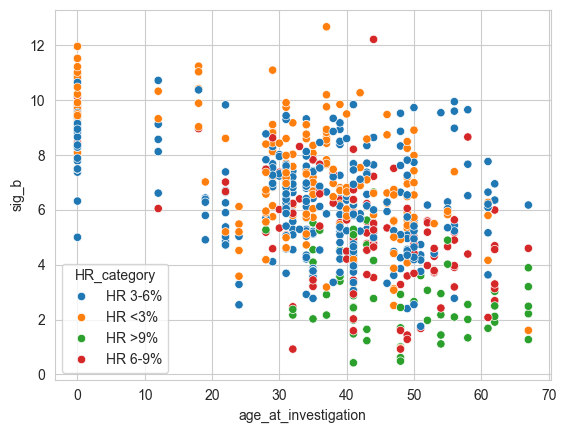

In [14]:
#scatterplot of age_at_investigation and sig_b
sns.scatterplot(data=df_final, x='age_at_investigation', y='sig_b', hue='HR_category')

In [15]:
df_final.to_csv(working_dir.joinpath('Dikes_Projects_Samples_Tests_2.csv'), index=False)

In [16]:
#count nan rows in df_bzs
df_vs.isna().sum()


borehole_id    0
sample_id      0
test_name      0
test_id        0
sample_name    0
pha_ini        0
pha_50         0
sig_cyc        0
sig_perm       0
E_ini          0
E_50           0
N_fat          0
dtype: int64

In [17]:
df_final.columns

Index(['borehole_id', 'project_dike_id', 'construction_year',
       'investigation_year', 'project_id', 'dike_id', 'project_name',
       'dike_name', 'waterboard', 'age_at_investigation', 'HR', 'bitumen',
       'sample_id_bzs', 'test_name_bzs', 'id', 'test_id_bzs',
       'sample_name_bzs', 'v', 'Sec_10', 'Sec_50', 'Sec_100', 'sig_b', 'eps_b',
       'G_c', 'G_c_over_eps_b', 'G_c_over_eps_b_sig_b', 'V_Ber',
       'sample_id_vs', 'test_name_vs', 'test_id_vs', 'sample_name_vs',
       'pha_ini', 'pha_50', 'sig_cyc', 'sig_perm', 'E_ini', 'E_50', 'N_fat',
       'HR_category'],
      dtype='object')

In [ ]:
subdir = working_dir.joinpath('per_borehole_scatterplots')
# relevant_columns = ['HR', 'bitumen', 'v', 'Sec_50', 'sig_b', 'eps_b',
#        'G_c', 'V_Ber', 'pha_ini', 'pha_50', 'sig_cyc', 'sig_perm', 'E_ini', 'E_50', 'N_fat']
relevant_columns = ['HR', 'bitumen', 'v', 'Sec_50', 'sig_b', 'eps_b',
       'G_c', 'V_Ber', 'pha_50', 'sig_perm', 'E_50', 'N_fat']

os.makedirs(subdir, exist_ok=True)
for col1 in relevant_columns:
    fig, ax = plt.subplots(ncols=3, nrows=4, figsize=(15,15))
    #first axes is a histogram of col1 with HR_category as hue

    #make a flat list of indices of ax except (0,0)
    ax_indices = [(i,j) for i in range(4) for j in range(3)]
    for count, col2 in enumerate(relevant_columns):
       if col1 == col2:
            sns.histplot(data=df_final, x=col1, kde=True, ax=ax[ax_indices[count]], hue='HR_category')
            ax[ax_indices[count]].set_title(f'Distribution of {col1}')
       else:
          sns.scatterplot(data=df_final, x=col1, y=col2, ax=ax[ax_indices[count]], hue='HR_category')
          if col2 == 'E_ini':
               ax[ax_indices[count]].set_ylim(top = 15000, bottom=0)
          if col2 == ' N_fat':
              ax[ax_indices[count]].set_yscale('log')
          ax[ax_indices[count]].set_xlabel(col1)
    plt.savefig(subdir.joinpath(f'{col1}_scatters.png'))
    plt.close()



In [19]:
#make new df, grouped by project_id with mean and std for 'v', 'Sec_10', 'Sec_50', 'Sec_100', 'sig_b', 'eps_b', 'G_c', 'G_c_over_eps_b', 'G_c_over_eps_b_sig_b', 'V_Ber' 'pha_ini', 'pha_50', 'sig_cyc', 'sig_perm', 'E_ini', 'E_50', 'N_fat', 'HR_category```

data_per_dike_project = pd.DataFrame.groupby(df_final, by='project_dike_id').agg({
    'v': ['mean', 'std'],
    'Sec_10': ['mean', 'std'],
    'Sec_50': ['mean', 'std'],
    'Sec_100': ['mean', 'std'], 
    'sig_b': ['mean', 'std'],
    'eps_b': ['mean', 'std'],
    'G_c': ['mean', 'std'],
    'G_c_over_eps_b': ['mean', 'std'],
    'G_c_over_eps_b_sig_b': ['mean', 'std'],
    'V_Ber': ['mean', 'std'],
    'pha_ini': ['mean', 'std'],
    'pha_50': ['mean', 'std'],
    'sig_cyc': ['mean', 'std'],
    'sig_perm': ['mean', 'std'],
    'E_ini': ['mean', 'std'],
    'E_50': ['mean', 'std'],
    'N_fat': ['mean', 'std'],
    'HR': ['mean', 'std']
})

#flatten multiindex columns
data_per_dike_project.columns = ['_'.join(col).strip() for col in data_per_dike_project.columns.values]

#for each parameter make a cov column based on mean and std
for col in data_per_dike_project.columns:
    if '_mean' in col:
        param = col.replace('_mean', '')
        data_per_dike_project[f'{param}_cov'] = data_per_dike_project[f'{param}_std'] / data_per_dike_project[col]
        
data_per_dike_project.head()



,v_mean,v_std,Sec_10_mean,Sec_10_std,Sec_50_mean,Sec_50_std,Sec_100_mean,Sec_100_std,sig_b_mean,sig_b_std,...,G_c_over_eps_b_sig_b_cov,V_Ber_cov,pha_ini_cov,pha_50_cov,sig_cyc_cov,sig_perm_cov,E_ini_cov,E_50_cov,N_fat_cov,HR_cov
project_dike_id,,,,,,,,,,,,,,,,,,,,,
1,0.093844,0.019691,952.185074,180.853928,599.677180,153.574214,385.040331,115.299052,5.379182,0.722684,...,0.050732,0.182109,0.095103,0.132260,0.383971,0.023174,0.107258,0.066684,1.074097,0.243259
2,0.348080,0.002700,913.580442,680.084374,970.651078,570.635936,743.028048,383.067598,5.285134,3.437769,...,0.094955,0.731564,0.237534,0.247500,0.645213,0.020906,0.283323,0.263836,1.155408,0.511842
3,0.386370,0.006486,1732.259664,703.274649,1308.739884,778.494279,915.028036,663.367396,5.914768,2.463763,...,0.101024,0.393429,0.316625,0.322590,0.504317,0.481863,0.191590,0.181850,1.926586,0.631492
4,0.368810,0.007970,2070.112815,896.167977,1236.164396,313.462115,799.807418,246.789354,6.150636,1.059072,...,0.047307,0.172058,0.119420,0.213178,0.346888,0.331629,0.142695,0.101209,1.637312,0.327297
5,0.377687,0.009828,4671.261950,2502.235735,3205.788647,2432.940100,2386.385606,1777.040035,6.726597,1.750334,...,0.187447,0.764546,0.259881,0.247774,0.382454,0.367135,0.140025,0.124461,1.278509,0.314560


In [20]:
subdir = working_dir.joinpath('per_dike_project_scatterplots')
os.makedirs(subdir, exist_ok=True)
for col1 in data_per_dike_project.columns:
    for col2 in data_per_dike_project.columns:
        if col1 != col2 and '_mean' in col1 and '_mean' in col2:
            if 'category' in col1 or 'category' in col2:
                continue
            fig, ax = plt.subplots(ncols=2, figsize=(10,5))
            sns.scatterplot(data=data_per_dike_project, x=col1, y=col2, ax=ax[0])
            ax[0].set_xlabel(col1)
            ax[0].set_ylabel(col2)
            #same but then for _cov
            param1 = col1.replace('_mean', '')
            param2 = col2.replace('_mean', '')
            sns.scatterplot(data=data_per_dike_project, x=f'{param1}_cov', y=f'{param2}_cov', ax=ax[1])
            ax[1].set_xlabel(f'{param1}_cov')
            ax[1].set_ylabel(f'{param2}_cov')
            plt.suptitle(f'{col1} vs {col2} - scatterplot of mean and cov')

            plt.savefig(subdir.joinpath(f'{col1}_vs_{col2}_scatter_new.png'))
            plt.close()



In [21]:
#take unique for project_dike_id in dikes_and_projects
unique_dike_projects = dikes_and_projects.drop_duplicates(subset=['project_dike_id'])

data_per_dike_project = pd.merge(unique_dike_projects, data_per_dike_project, left_on='project_dike_id', right_index=True, how='right')
data_per_dike_project.reset_index(drop=True, inplace=True)
data_per_dike_project.head()

,borehole_id,project_dike_id,construction_year,investigation_year,project_id,dike_id,project_name,dike_name,waterboard,age_at_investigation,...,G_c_over_eps_b_sig_b_cov,V_Ber_cov,pha_ini_cov,pha_50_cov,sig_cyc_cov,sig_perm_cov,E_ini_cov,E_50_cov,N_fat_cov,HR_cov
0,1,1,1984,2006,1,1,P_0601831,"het_flaauwe_werk_29,6 - 48,5",Hollandse Delta,22,...,0.050732,0.182109,0.095103,0.132260,0.383971,0.023174,0.107258,0.066684,1.074097,0.243259
1,9,2,1959,2007,2,2,P_0702493,hellegatsdam_-,Rijkswaterstaat Zuid-Holland Waterdistrict Har...,48,...,0.094955,0.731564,0.237534,0.247500,0.645213,0.020906,0.283323,0.263836,1.155408,0.511842
2,25,3,1977,2009,3,3,P_0802158,"t_schoor_-_veerdam_holwerd_40,7 - 49,75",Wetterskip Fryslân,32,...,0.101024,0.393429,0.316625,0.322590,0.504317,0.481863,0.191590,0.181850,1.926586,0.631492
3,34,4,1977,2009,3,4,P_0802158,"zurichoord_6,55 - 7,4",Wetterskip Fryslân,32,...,0.047307,0.172058,0.119420,0.213178,0.346888,0.331629,0.142695,0.101209,1.637312,0.327297
4,18,5,1975,2009,3,5,P_0802158,"paesens_-_wierum_49,75 - 55,3",Wetterskip Fryslân,34,...,0.187447,0.764546,0.259881,0.247774,0.382454,0.367135,0.140025,0.124461,1.278509,0.314560


In [22]:
#make categories for HR_mean
data_per_dike_project['HR_mean_category'] = data_per_dike_project.HR_mean.apply(categorize_hr)
#make categories for HR_std using pd cut
data_per_dike_project['HR_std_category'] = pd.cut(data_per_dike_project.HR_std, bins=[0, 0.5, 1, 1.5, 2], labels=['low', 'medium', 'high', 'very high'])
#and cov
data_per_dike_project['HR_cov_category'] = pd.cut(data_per_dike_project.HR_cov, bins=[0, 0.1, 0.3, 0.5, 1], labels=['low', 'medium', 'high', 'very high'])


In [23]:
data_per_dike_project

,borehole_id,project_dike_id,construction_year,investigation_year,project_id,dike_id,project_name,dike_name,waterboard,age_at_investigation,...,pha_50_cov,sig_cyc_cov,sig_perm_cov,E_ini_cov,E_50_cov,N_fat_cov,HR_cov,HR_mean_category,HR_std_category,HR_cov_category
0,1,1,1984,2006,1,1,P_0601831,"het_flaauwe_werk_29,6 - 48,5",Hollandse Delta,22,...,0.132260,0.383971,0.023174,0.107258,0.066684,1.074097,0.243259,HR 3-6%,medium,medium
1,9,2,1959,2007,2,2,P_0702493,hellegatsdam_-,Rijkswaterstaat Zuid-Holland Waterdistrict Har...,48,...,0.247500,0.645213,0.020906,0.283323,0.263836,1.155408,0.511842,HR 6-9%,NaN,very high
2,25,3,1977,2009,3,3,P_0802158,"t_schoor_-_veerdam_holwerd_40,7 - 49,75",Wetterskip Fryslân,32,...,0.322590,0.504317,0.481863,0.191590,0.181850,1.926586,0.631492,HR 3-6%,NaN,very high
3,34,4,1977,2009,3,4,P_0802158,"zurichoord_6,55 - 7,4",Wetterskip Fryslân,32,...,0.213178,0.346888,0.331629,0.142695,0.101209,1.637312,0.327297,HR 3-6%,high,high
4,18,5,1975,2009,3,5,P_0802158,"paesens_-_wierum_49,75 - 55,3",Wetterskip Fryslân,34,...,0.247774,0.382454,0.367135,0.140025,0.124461,1.278509,0.314560,HR 3-6%,high,high
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
84,648,85,1976,2023,34,83,P_2301408,schoor-wierum_,HHNK,47,...,NaN,NaN,NaN,NaN,NaN,NaN,0.321984,HR <3%,medium,high
85,663,86,1953,2014,35,24,P_1400863,"van_pallandtdijk_13,45 - 15,85",Hollandse Delta,61,...,NaN,NaN,NaN,NaN,NaN,NaN,0.604408,HR 3-6%,NaN,very high
86,667,87,1965,2014,35,31,P_1400863,"lauwersmeerdijk_friesland_57,5 - 61,8",Wetterskip Fryslân,49,...,NaN,NaN,NaN,NaN,NaN,NaN,0.421306,HR 3-6%,NaN,high
87,679,88,1970,2014,35,85,P_1400863,"pettemer_zeewering_20,9 - 22",Hollandse Delta,44,...,NaN,NaN,NaN,NaN,NaN,NaN,0.380546,HR 6-9%,NaN,high


<Axes: xlabel='age_at_investigation', ylabel='v_mean'>

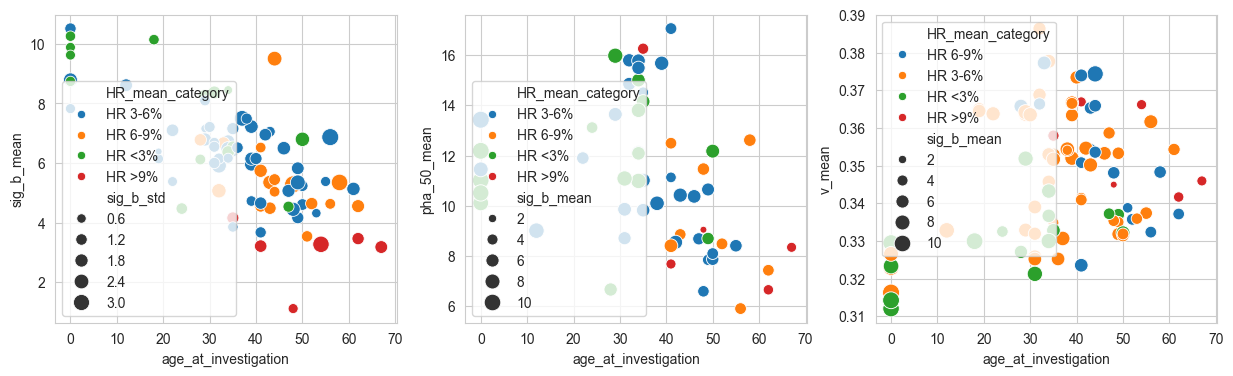

In [24]:
fig, ax = plt.subplots(figsize=(15,4), ncols=3)

sns.scatterplot(data=data_per_dike_project, x='age_at_investigation', y='sig_b_mean', hue='HR_mean_category', ax=ax[0], sizes=(25, 150), size = 'sig_b_std')
sns.scatterplot(data=data_per_dike_project, x='age_at_investigation', y='pha_50_mean', hue='HR_mean_category', ax=ax[1], sizes=(25, 150), size = 'sig_b_mean')
sns.scatterplot(data=data_per_dike_project.loc[data_per_dike_project.v_mean >0.25], x='age_at_investigation', y='v_mean', hue='HR_mean_category', ax=ax[2], sizes=(25, 150), size = 'sig_b_mean')


<Axes: xlabel='age_at_investigation', ylabel='sig_b_std'>

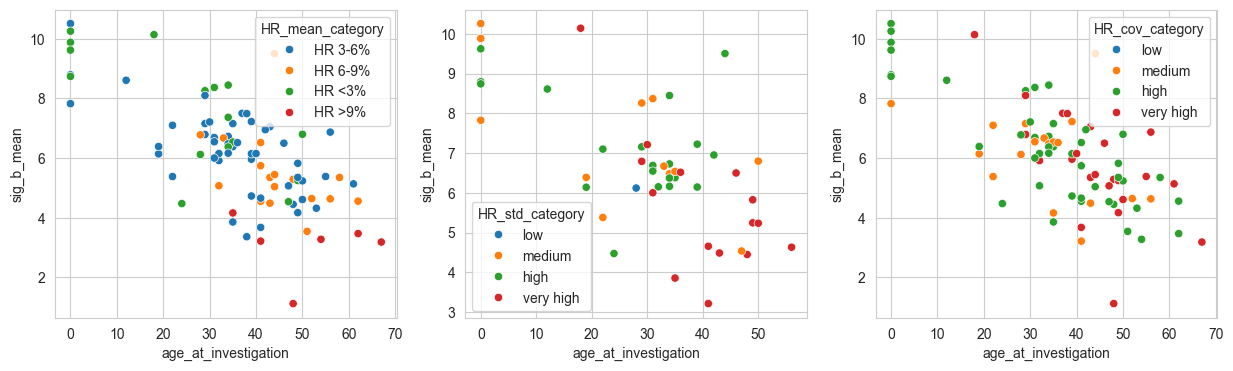

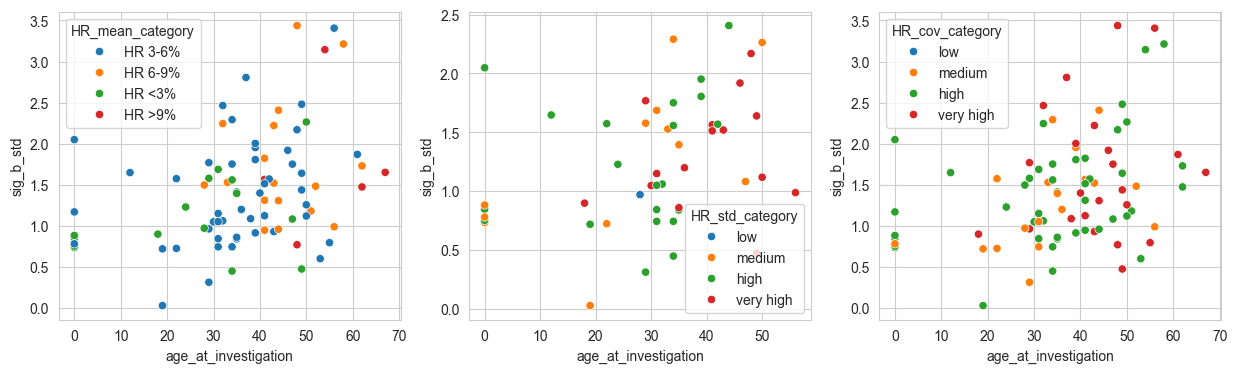

In [25]:
#plot sig_b_mean and age_at_investigation
fig, ax = plt.subplots(figsize=(15,4), ncols=3)
sns.scatterplot(data=data_per_dike_project, x='age_at_investigation', y='sig_b_mean', hue='HR_mean_category', ax=ax[0])

#same with std as hue
sns.scatterplot(data=data_per_dike_project, x='age_at_investigation', y='sig_b_mean', hue='HR_std_category', ax=ax[1])

#and cov as hue
sns.scatterplot(data=data_per_dike_project, x='age_at_investigation', y='sig_b_mean', hue='HR_cov_category', ax=ax[2])

fig,ax = plt.subplots(figsize=(15,4), ncols=3)
sns.scatterplot(data=data_per_dike_project, x='age_at_investigation', y='sig_b_std', hue='HR_mean_category', ax=ax[0])

sns.scatterplot(data=data_per_dike_project, x='age_at_investigation', y='sig_b_std', hue='HR_std_category', ax=ax[1])

sns.scatterplot(data=data_per_dike_project, x='age_at_investigation', y='sig_b_std', hue='HR_cov_category', ax=ax[2])

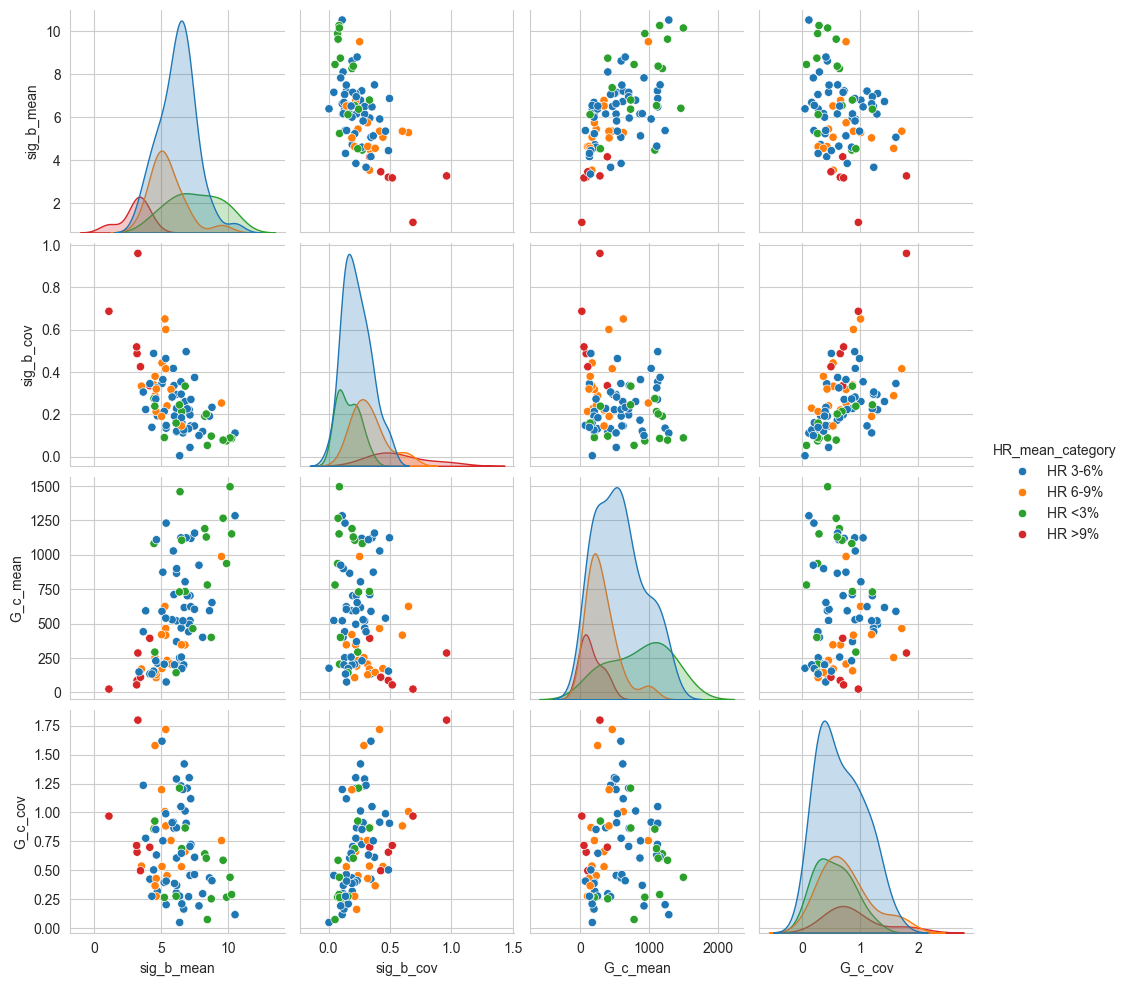

In [26]:
#correlation plots for sig_b mean, std and HR mean, std
sns.pairplot(data_per_dike_project, vars=['sig_b_mean', 'sig_b_cov', 'G_c_mean', 'G_c_cov'], hue = 'HR_mean_category')

C:\Users\klerk_wj\AppData\Local\Temp\ipykernel_3420\2932064084.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(data=df_final, x='project_dike_id', y='HR', jitter=True, palette='Set2')


<Axes: xlabel='project_dike_id', ylabel='HR'>

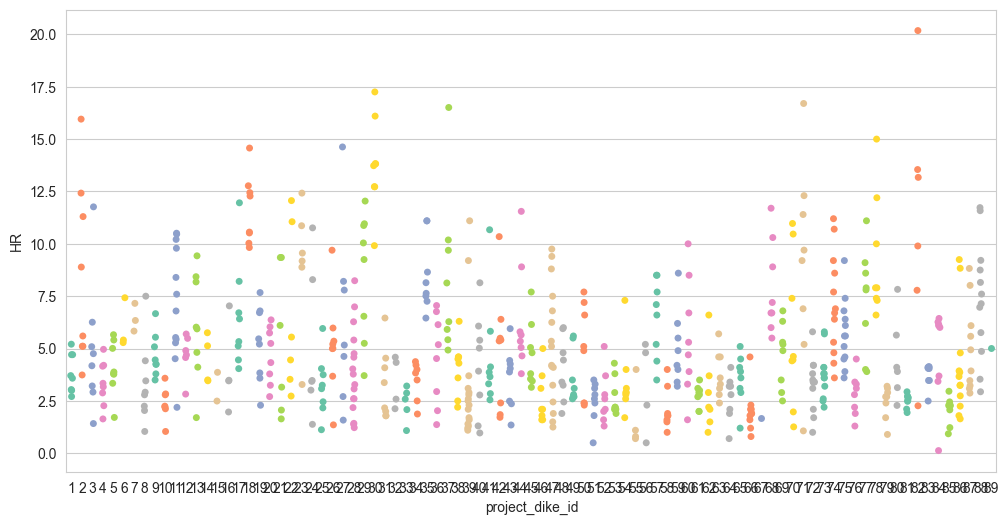

In [27]:
#make a violinplot of HR per project_dike_id 
plt.figure(figsize=(12,6))
sns.stripplot(data=df_final, x='project_dike_id', y='HR', jitter=True, palette='Set2')

<Axes: xlabel='construction_year', ylabel='HR_cov'>

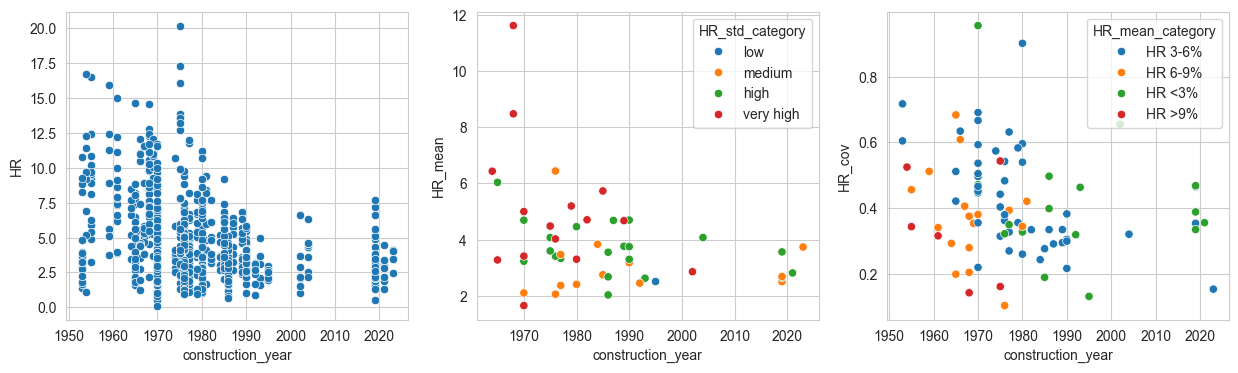

In [28]:
fig, ax = plt.subplots(figsize=(15,4), ncols = 3)
#scatterplot of construction_year vs HR
sns.scatterplot(data=df_final, x='construction_year', y='HR', ax=ax[0])
sns.scatterplot(data=data_per_dike_project, x='construction_year', y='HR_mean', hue = 'HR_std_category', ax=ax[1])
sns.scatterplot(data=data_per_dike_project, x='construction_year', y='HR_cov', hue = 'HR_mean_category', ax=ax[2])

<Axes: xlabel='age_at_investigation', ylabel='sig_b_std'>

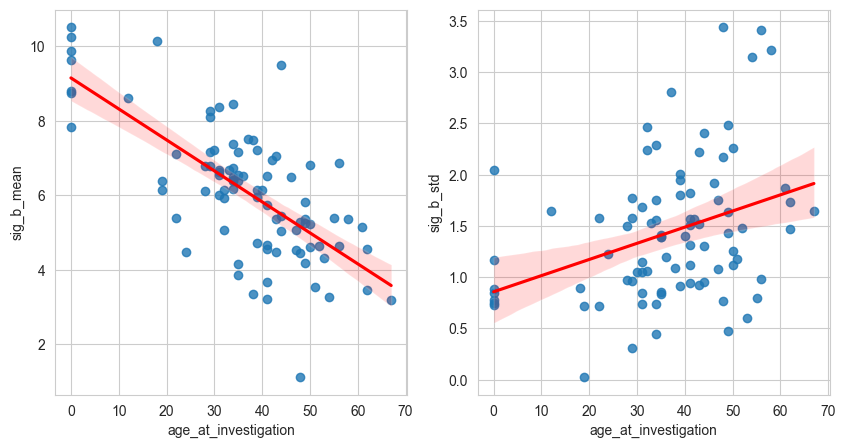

In [29]:
fig, ax = plt.subplots(ncols=2, figsize=(10,5))

sns.regplot(data=data_per_dike_project, x='age_at_investigation', y='sig_b_mean', scatter=True, ax=ax[0], x_ci='ci', ci=95, line_kws={'color': 'red'})
sns.regplot(data=data_per_dike_project, x='age_at_investigation', y='sig_b_std', scatter=True, ax=ax[1], x_ci='ci', ci=95, line_kws={'color': 'red'})

<Axes: xlabel='age_at_investigation', ylabel='sig_b_mean'>

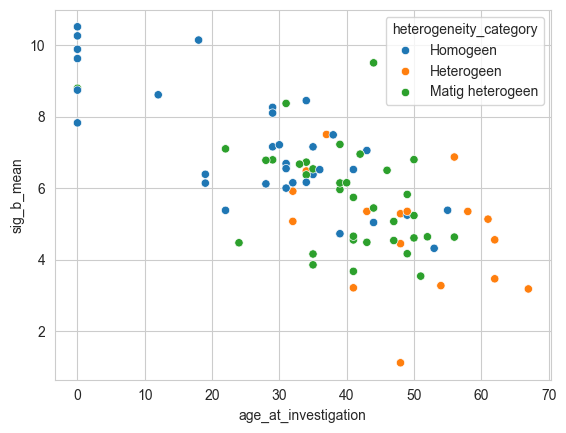

In [30]:
#In data_per_dike_project, make a new column called heterogeneity category based on sig_b_cov
def categorize_heterogeneity(cov):
    if cov < 0.2:
        return 'Homogeen'
    elif 0.2 <= cov < 0.35:
        return 'Matig heterogeen'
    elif cov >= 0.35:
        return 'Heterogeen'

data_per_dike_project['heterogeneity_category'] = data_per_dike_project['sig_b_cov'].apply(categorize_heterogeneity)

#scatterplot of age_at_investigation vs sig_b_mean, colored by heterogeneity_category
sns.scatterplot(data=data_per_dike_project, x='age_at_investigation', y='sig_b_mean', hue='heterogeneity_category', palette='tab10')


<Axes: xlabel='age_at_investigation', ylabel='G_c_cov'>

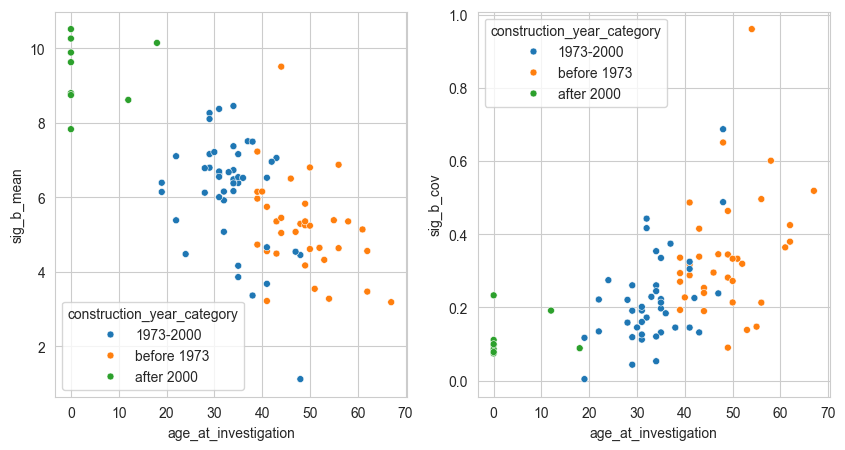

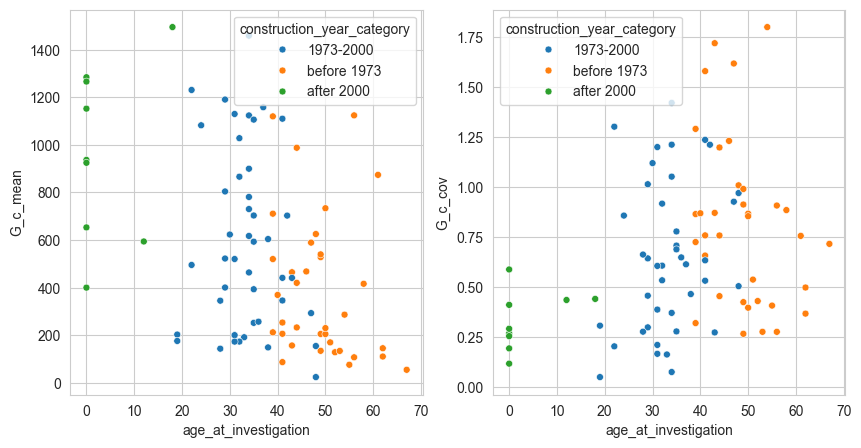

In [31]:
#alles van voor 1973: raus
#construction categories before 1973, between 1973 and 2000 and after 2000
def categorize_annum(year):
    if year < 1973:
        return 'before 1973'
    elif 1973 <= year < 2000:
        return '1973-2000'
    else:
        return 'after 2000'
data_per_dike_project['construction_year_category'] = data_per_dike_project.construction_year.apply(categorize_annum)

fig, ax = plt.subplots(figsize=(10,5), ncols=2)
sns.scatterplot(data=data_per_dike_project, x='age_at_investigation', y='sig_b_mean', hue='construction_year_category', ax=ax[0], s=25)
sns.scatterplot(data=data_per_dike_project, x='age_at_investigation', y='sig_b_cov', hue='construction_year_category', ax=ax[1], s=25)

fig, ax = plt.subplots(figsize=(10,5), ncols=2)
sns.scatterplot(data=data_per_dike_project, x='age_at_investigation', y='G_c_mean', hue='construction_year_category', ax=ax[0], s=25)
sns.scatterplot(data=data_per_dike_project, x='age_at_investigation', y='G_c_cov', hue='construction_year_category', ax=ax[1], s=25)


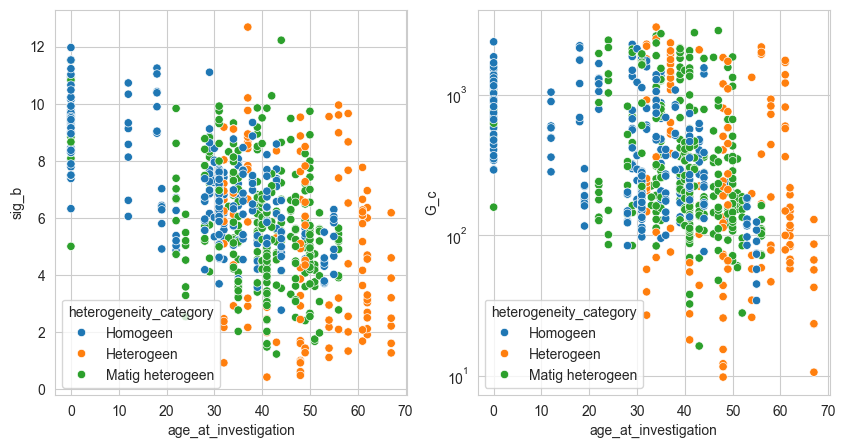

In [32]:
#heterogeniteitscategorie: maak een dict van project_dike_id en de corresponderende heterogeniteitscategorie o.b.v. data_per_dike_project
heterogeneity_dict = data_per_dike_project.set_index('project_dike_id')['heterogeneity_category'].to_dict()
heterogeneity_dict
#toevoegen aan df_final
df_final['heterogeneity_category'] = df_final['project_dike_id'].map(heterogeneity_dict)
fig, ax = plt.subplots(figsize=(10,5), ncols=2)
sns.scatterplot(data=df_final, x='age_at_investigation', y='sig_b', hue='heterogeneity_category', palette='tab10', ax=ax[0])
sns.scatterplot(data=df_final, x='age_at_investigation', y='G_c', hue='heterogeneity_category', palette='tab10', ax=ax[1])
ax[1].set_yscale('log')

<Axes: xlabel='G_c', ylabel='sig_b'>

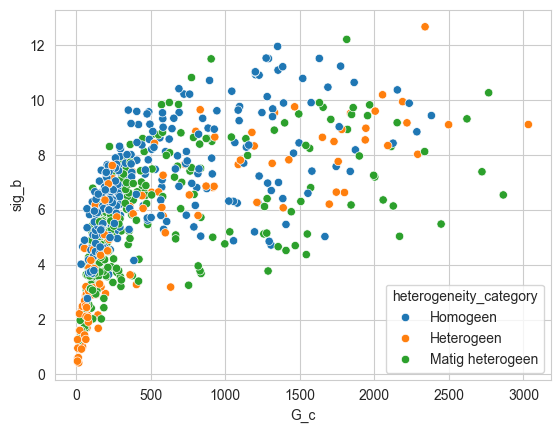

In [33]:
#scatter G_c vs sig_b, colored by heterogeneity_category
sns.scatterplot(data=df_final, x='G_c', y='sig_b', hue='heterogeneity_category', palette='tab10')

<Axes: xlabel='V_Ber', ylabel='sig_b'>

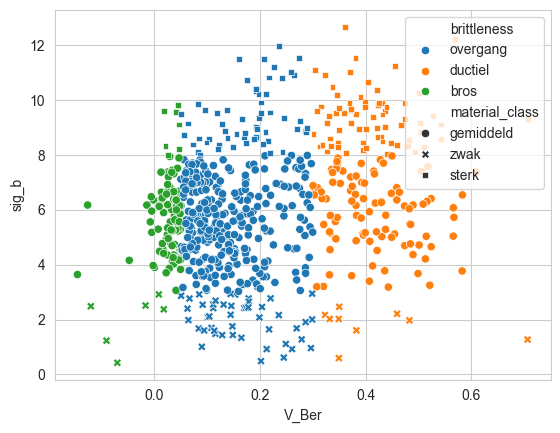

In [34]:
#classificeren bros & ductiel op basis van sig_b en V_ber
#V_Ber < 0.05: bros
#V_Ber 0.05-0.3: overgang
#sig_b < 3: zwak
#sig_b 3-8: gemiddeld
#sig_b > 8: sterk
def classify_brittleness(row):
    if row['V_Ber'] < 0.05:
        brittleness = 'bros'
    elif 0.05 <= row['V_Ber'] <= 0.3:
        brittleness = 'overgang'
    else:
        brittleness = 'ductiel'
    return brittleness

def classify_material_strength(row):
    if row['sig_b'] < 3:
        strength = 'zwak'
    elif 3 <= row['sig_b'] <= 8:
        strength = 'gemiddeld'
    else:
        strength = 'sterk'
        
    return strength

df_final['brittleness'] = df_final.apply(classify_brittleness, axis=1)
df_final['material_class'] = df_final.apply(classify_material_strength, axis=1)

sns.scatterplot(data=df_final, x='V_Ber', y='sig_b', hue='brittleness',style='material_class', palette='tab10')

<Axes: xlabel='age_at_investigation', ylabel='sig_b'>

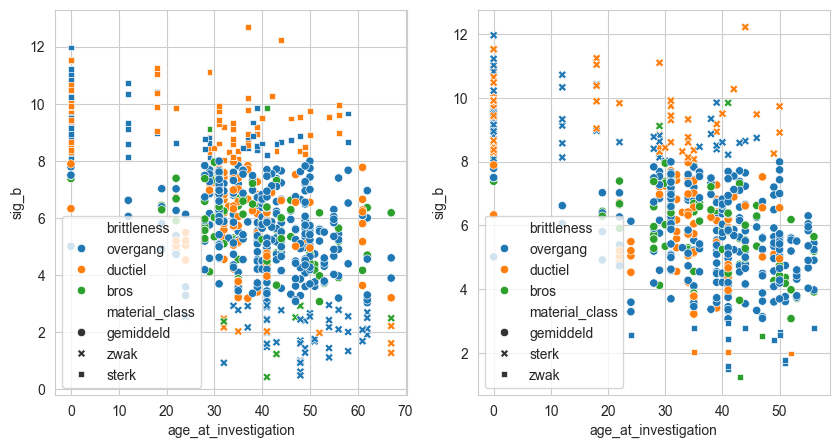

In [35]:
fig, ax = plt.subplots(figsize=(10,5), ncols=2)
sns.scatterplot(data=df_final, x='age_at_investigation', y='sig_b', hue='brittleness', style='material_class', palette='tab10', ax=ax[0])
sns.scatterplot(data=df_final.loc[df_final.heterogeneity_category != 'Heterogeen'], x='age_at_investigation', y='sig_b', hue='brittleness', style='material_class', palette='tab10', ax=ax[1])


<Axes: xlabel='pha_50', ylabel='Count'>

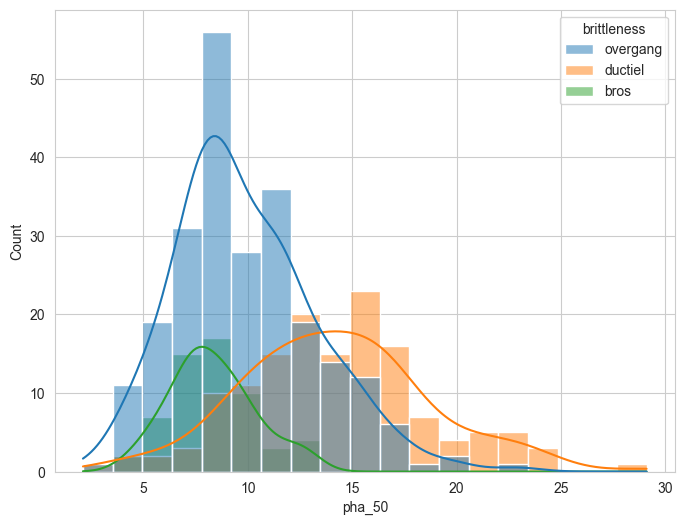

In [36]:
#make a histplot of pha_50 by brittleness
plt.figure(figsize=(8,6))
sns.histplot(data=df_final, x='pha_50', hue='brittleness', kde=True, palette='tab10', alpha=0.5)


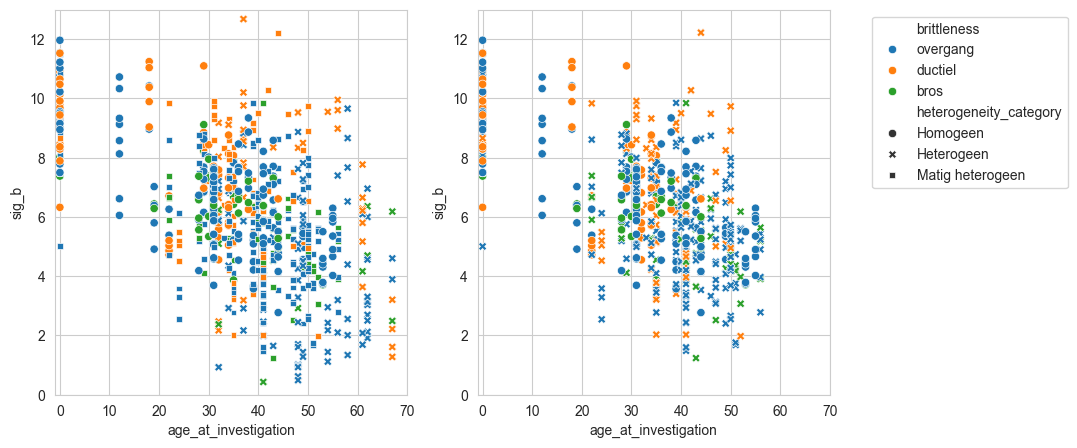

In [37]:
fig, ax = plt.subplots(figsize=(10,5), ncols=2)
sns.scatterplot(data=df_final, x='age_at_investigation', y='sig_b', hue='brittleness', style='heterogeneity_category', palette='tab10', ax=ax[0])
sns.scatterplot(data=df_final.loc[df_final.heterogeneity_category != 'Heterogeen'], x='age_at_investigation', y='sig_b', hue='brittleness', style='heterogeneity_category', palette='tab10', ax=ax[1])

ax[0].set_ylim(0,13)
ax[1].set_ylim(0,13)
ax[0].set_xlim(-1,70)
ax[1].set_xlim(-1,70)
#put ax[0] legend right outside of everything. Omit the legend for ax[1]
ax[0].legend(loc='upper left', bbox_to_anchor=(2.3, 1))
ax[1].legend().set_visible(False)


<Axes: xlabel='pha_50', ylabel='sig_b'>

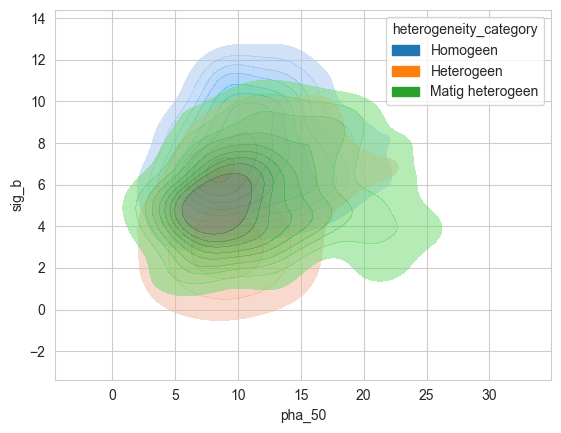

In [38]:
#scatter V_ber vs sig_b, colored by heterogeneity_category
sns.kdeplot(data=df_final, x='pha_50', y='sig_b', hue='heterogeneity_category', palette='tab10', fill=True,alpha=0.5)
# sns.kdeplot(data=df_final, x='pha_50', y='sig_b', hue='heterogeneity_category', palette='tab10', fill=True,alpha=0.5)

<Axes: xlabel='age_at_investigation', ylabel='sig_b_mean'>

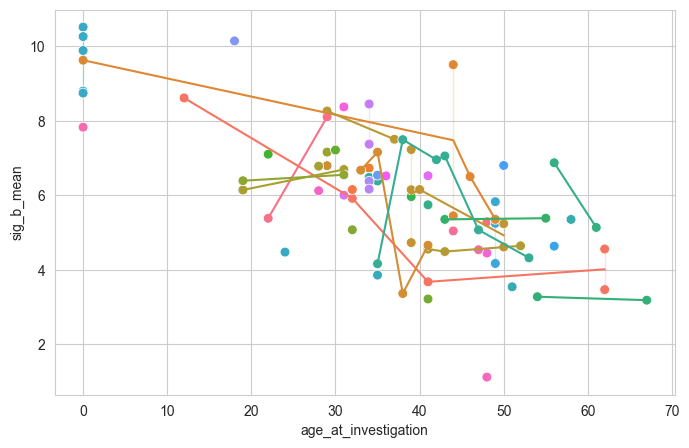

In [39]:
hoofddijk = data_per_dike_project.dike_name.apply(lambda x: x.split('_')[0])
data_per_dike_project['hoofddijk'] = hoofddijk

fig,ax = plt.subplots(figsize=(8,5))
sns.scatterplot(data=data_per_dike_project, x='age_at_investigation', y='sig_b_mean', hue='hoofddijk', s=50, ax=ax, legend = False)
sns.lineplot(data=data_per_dike_project, x='age_at_investigation', y='sig_b_mean', hue='hoofddijk',markers=True,ax=ax, legend= False)

<Axes: xlabel='age_at_investigation', ylabel='V_Ber'>

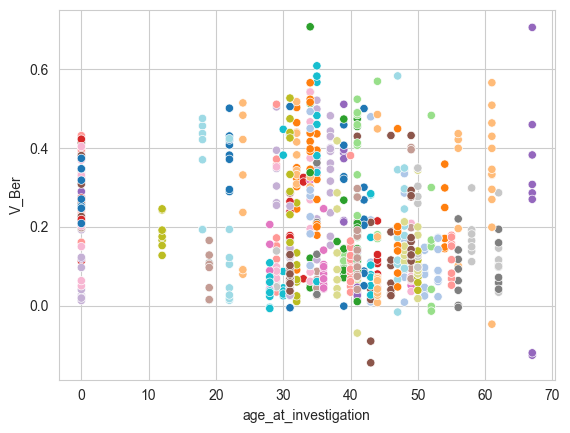

In [40]:
sns.scatterplot(data=df_final, x='age_at_investigation', y='V_Ber',hue = 'dike_id', palette='tab20',legend=False)

<Axes: xlabel='sig_b', ylabel='eps_b'>

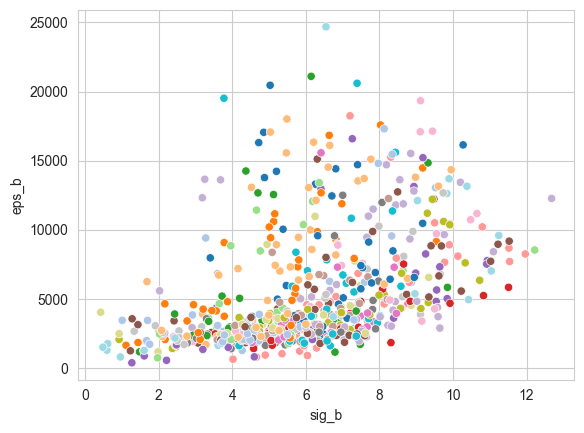

In [41]:
sns.scatterplot(data=df_final, x='sig_b', y='eps_b',hue = 'dike_id', palette='tab20',legend=False)

Fasehoek = 12.8


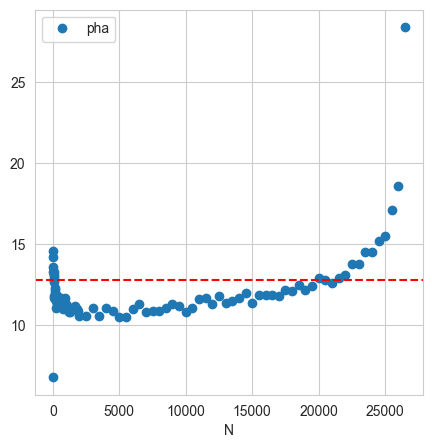

In [42]:
#from VermoeiingProcessed import everything related to sample_name = K1-b2
sample_name = 'K2-b2b'
query = f"""
SELECT
    vsp.*
FROM VermoeiingProcessed vsp
WHERE vsp.sample_name = '{sample_name}'
"""
df_k1b2 = pd.read_sql(query, conn)

fig, ax = plt.subplots(figsize=(5,5))
df_k1b2.plot(x='N', y='pha', linestyle = '', marker='o',ax=ax)
ax.axhline(y=df_final.loc[df_final.sample_name_vs == 'K1-b2', 'pha_50'].values[0], color='r', linestyle='--')


#get phase angle from df_final
print(f'Fasehoek = {df_final.loc[df_final.sample_name_vs == 'K1-b2', 'pha_50'].values[0]}')

In [43]:
df_bzs

,borehole_id,sample_id,test_name,id,test_id,sample_name,v,Sec_10,Sec_50,Sec_100,sig_b,eps_b,G_c,G_c_over_eps_b,G_c_over_eps_b_sig_b,V_Ber
0,1,1,T_k1-b1,1,1,k1-b1,0.140012,845.411263,682.612478,469.888848,6.259762,13307.685104,1220.385972,0.091705,0.014650,0.289319
1,2,4,T_k2-b1,2,4,k2-b1,0.096297,1212.461276,772.955418,535.381092,5.381163,10049.202919,790.309841,0.078644,0.014615,0.294647
2,3,7,T_k3-b1,3,7,k3-b1,0.082952,937.031495,579.948853,352.859425,4.876932,13780.406940,1056.284704,0.076651,0.015717,0.381887
3,4,10,T_k4-b1,4,10,k4-b1,0.083127,1180.725811,828.712848,537.120868,6.708308,12456.420151,1309.306443,0.105111,0.015669,0.371331
4,5,13,T_k5-b1,5,13,k5-b1,0.083283,955.572918,500.039983,289.317153,4.720396,16308.786975,1308.015356,0.080203,0.016991,0.501078
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
678,693,1230,T_5B,679,1230,5B,0.353458,959.276071,705.690675,412.857538,6.649675,16108.971986,1745.405347,0.108350,0.016294,0.463557
679,694,1231,T_6B,680,1231,6B,0.354706,1197.529767,938.497521,612.411586,5.799059,9464.832608,818.279228,0.086455,0.014908,0.333151
680,695,1232,T_7B,681,1232,7B,0.357414,434.310620,378.055065,268.423457,1.683714,6260.415820,148.956316,0.023793,0.014131,0.269361
681,696,1233,T_8B,682,1233,8B,0.353076,1028.788090,671.315236,380.702979,6.211900,16340.261329,1698.176531,0.103926,0.016730,0.508694


In [44]:
df_bzs.loc[df_bzs.sample_name == '22A']

,borehole_id,sample_id,test_name,id,test_id,sample_name,v,Sec_10,Sec_50,Sec_100,sig_b,eps_b,G_c,G_c_over_eps_b,G_c_over_eps_b_sig_b,V_Ber
298,303,531,T_22A,299,531,22A,0.360462,3377.241189,2327.849144,2085.047327,3.615347,1659.84,77.992179,0.046988,0.012997,0.115205


Area under curve = 0.17377280000000006 J/mm^2
Area for triangle = 1.2917771999999998 J/mm^2
Vormfactor = -0.8654777309895235
Breukenergie Gc = 66.2981671677324 J/m^2


,borehole_id,sample_id,test_name,id,test_id,sample_name,v,Sec_10,Sec_50,Sec_100,sig_b,eps_b,G_c,G_c_over_eps_b,G_c_over_eps_b_sig_b,V_Ber
298,303,531,T_22A,299,531,22A,0.360462,3377.241189,2327.849144,2085.047327,3.615347,1659.84,77.992179,0.046988,0.012997,0.115205


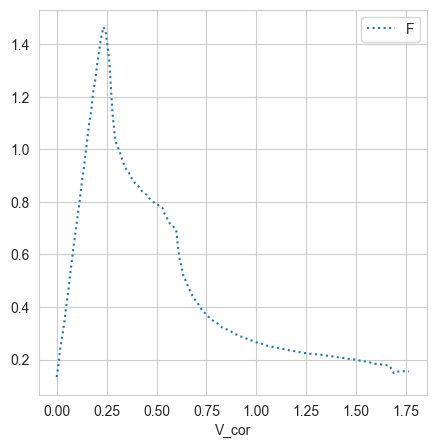

In [45]:
#bezwijksterkte processed for sample 22A
sample_name = '22A'
query = f"""
SELECT
    bsp.*
FROM BezwijksterkteProcessed bsp
WHERE bsp.sample_name = '{sample_name}'
"""

df_k1b1_bsp = pd.read_sql(query, conn)
df_k1b1_bsp.head()

fig, ax = plt.subplots(figsize=(5,5))
df_k1b1_bsp.plot(x='V_cor', y='F', linestyle = ':', ax=ax)

#calculate area under graph using trapezoidal rule


    # # Rek bij breuk en vormfactor
    # Gc = area / (D * h)  # Gecorrigeerde breukenergie
D = 0.0518
h=0.0506
import numpy as np
#find max of df_ki1b1_bsp['F'] 
idx_max = np.argmax(df_k1b1_bsp['F'])
#calculate area under curve in J/mm^2 from origin to max F
area = numpy.trapezoid(df_k1b1_bsp['F'][0:idx_max] *1000 , df_k1b1_bsp['V_cor'][0:idx_max]/1000)
print(f'Area under curve = {area} J/mm^2')
area_for_triangle = .5 * df_k1b1_bsp['F'].max() * df_k1b1_bsp['V_cor'].max()
print(f'Area for triangle = {area_for_triangle} J/mm^2')
#vormfactor is (area-area_for_triangle)/area_for_triangle
vormfactor = (area-area_for_triangle)/area_for_triangle
print(f'Vormfactor = {vormfactor}')
#breukenergie Gc
Gc = area / (D * h)
print(f'Breukenergie Gc = {Gc} J/m^2')

df_bzs.loc[df_bzs.sample_name == f'{sample_name}']

<Axes: xlabel='age_at_investigation', ylabel='sig_b'>

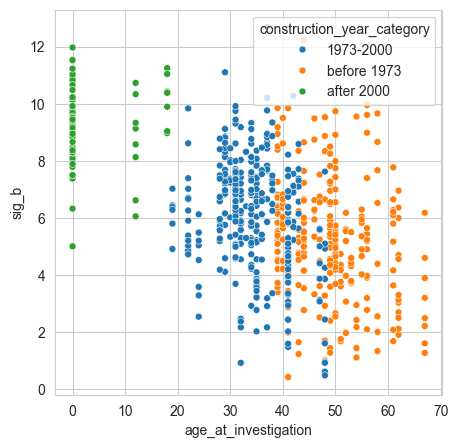

In [46]:
df_final['construction_year_category'] = df_final.construction_year.apply(categorize_annum)

fig, ax = plt.subplots(figsize=(5,5))
sns.scatterplot(data=df_final, x='age_at_investigation', y='sig_b', hue='construction_year_category', ax=ax, s=25)


<Axes: xlabel='age_at_investigation', ylabel='sig_b_mean'>

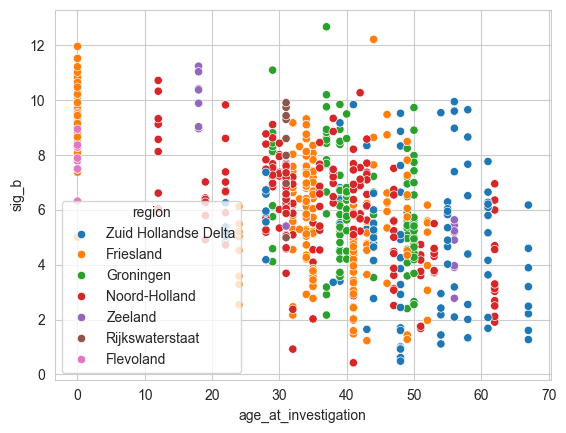

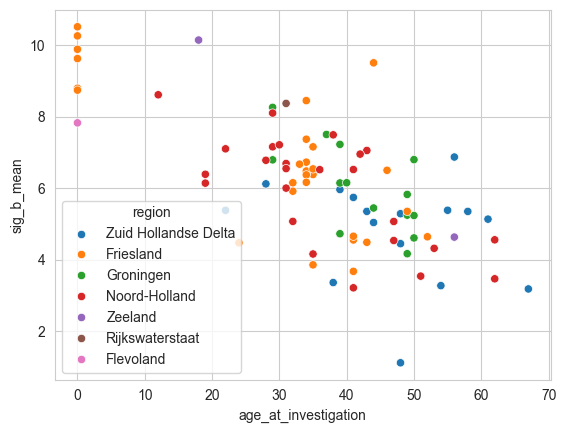

In [47]:
df_final['waterboard'].unique()
#translation dictionary to get consistent names:
region_dict = {'Hollandse Delta': 'Zuid Hollandse Delta',
 'Rijkswaterstaat Zuid-Holland Waterdistrict Haringvliet': 'Zuid Hollandse Delta',
'Wetterskip Fryslân': 'Friesland', 
'Noorderzijlvest': 'Groningen',
"{'emmapolder_47,5 - 57': 'Noorderzijlvest'}": 'Groningen',
"{'noorderhavendam_0 - 1,206': 'Wetterskip Fryslân'}": "Friesland",
"HHNK": "Noord-Holland",
'Waterschap Noorderzijlvest': "Groningen",
"{'zuidelijke_dijken_goeree_vak_1_42,525 - 43,04': 'Hollandse Delta'}": 'Zuid Hollandse Delta',
'PWN': "Noord-Holland", 'Groningen Seaports': "Groningen", 'Waterschap Scheldestromen': "Zeeland",
'Waterschap Hollandse Delta': "Zuid Hollandse Delta", 'Rijkswaterstaat': "Rijkswaterstaat",
'Havenbedrijf Rotterdam': "Zuid Hollandse Delta", 'Waterschap Zuiderzeeland': "Flevoland"}
df_final['region'] = df_final['waterboard'].map(region_dict)

#plot age_at_investigation vs sig_b, colored by region
plt.subplots()
sns.scatterplot(data=df_final, x='age_at_investigation', y='sig_b', hue='region', palette='tab10')

#also map to data_per_dike_project
data_per_dike_project['region'] = data_per_dike_project['waterboard'].map(region_dict)
#plot age_at_investigation vs sig_b_mean, colored by 
plt.subplots()
sns.scatterplot(data=data_per_dike_project, x='age_at_investigation', y='sig_b_mean', hue='region', palette='tab10')